In [22]:
## Load in the confocal data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Results dataframes
confocal_df = pd.read_csv("../output/confocal_results_df_batch.csv")
idealised_df = pd.read_csv("../output/idealised_chosen_results.csv")

## Set the colours for the three mesh types
colours = {
    'empirical': 'magenta',
    'anisotropic': "#8A0CA1",
    'idealised_circular': 'orange',
    'idealised_oval': 'green',
    'midsection' : 'black',
    'tip' : "#CC79A7"
}

# Set the default font size for all plots
plt.rcParams.update({'font.size': 14})

## Set the name for each mesh
mesh_dcr = "Sample"

## Choose meshes to include based on their pore length : length
stomata_length = [43, 40,40.5, 48.2, 45.2, 40.3, 37, 39.6, 37.5, 36, 40, 42.1, 41.6, 40.6, 40.5, 45.5, 41]
pore_length = [13.1, 12.6, 13.6, 13.6, 16.6, 14.0, 12.2, 14.7, 10.8, 6.8, 13.0, 8.7, 11.2, 6.7, 11.9, 14.3, 11.3]
mesh_ids =["1_2","1_3","1_4","1_5","1_6","1_8","2_1", "2_3", "2_6a", "2_6b", "2_7","3_1","3_2", "3_3", "3_4","3_6", "3_7"]
print(len(mesh_ids))

pore_proportion = [p / s for p, s in zip(pore_length, stomata_length)]

threshold = 0.25
prop_mask = [p > threshold for p in pore_proportion]
selected_meshes = [m for m, keep in zip(mesh_ids, prop_mask) if keep]
print("Selected meshes:", selected_meshes)


17
Selected meshes: ['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a', '2_7', '3_2', '3_4', '3_6', '3_7']


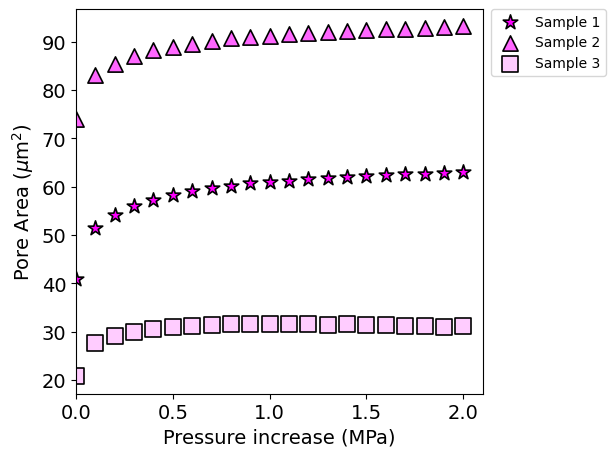

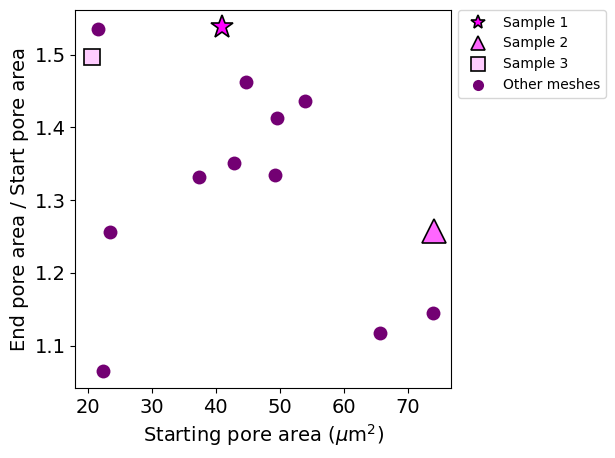

In [2]:
## Figure 1
import importlib
import plot_fig1 as pf1
importlib.reload(pf1)

pf1.run_plot_fig1(confocal_df=confocal_df, colours=colours, mesh_dcr=mesh_dcr)

Paired t-test: p = 1.6e-07
Wilcoxon signed-rank: p = 2.46e-07


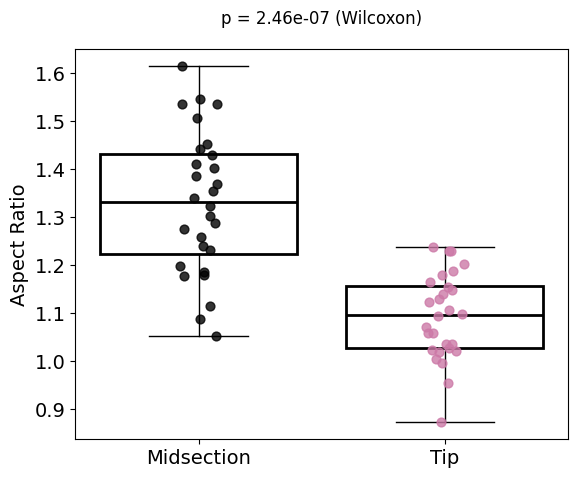

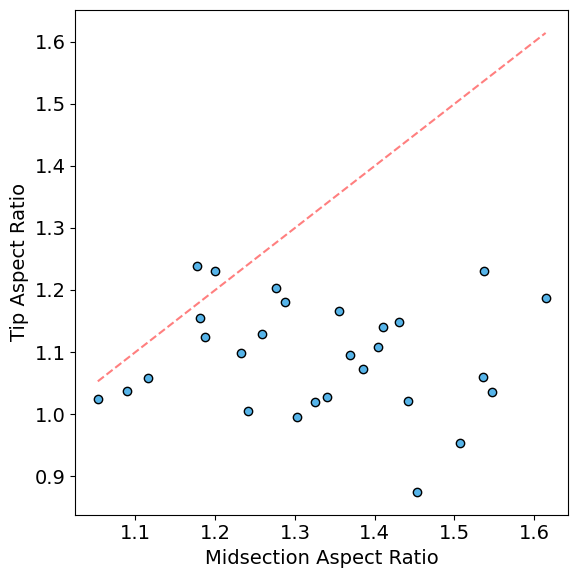

In [3]:
## Plot Figure 2
import importlib
import plot_fig2 as pf2
importlib.reload(pf2)
pf2.run_plot_fig2(confocal_df=confocal_df, colours=colours)



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
## Figure 3: 
## a) Cross-sectional aspect ratio drives geometry-derived stomatal opening

## Load in the idealised results
df_idealised = pd.read_csv("../output/idealised_results_df.csv")
df_idealised_pore_area = pd.read_csv("../output/idealised_results_pore_area_df.csv")
df_idealised_cross_section = pd.read_csv("../output/idealised_results_cross_sections_df.csv")

## Combine our dataframes into a single dataframe
df_combined = df_idealised_pore_area.merge(df_idealised_cross_section, on=["Mesh ID", "Pressure", "Cross-section type"])

df_combined.head()

,Mesh ID,Cross-section type,Pressure,Pore Area,Cross section,Aspect Ratio
0,2_6a,circular,0.8,19.8944,[[-1.89380e+00 3.70945e-06]\n [-1.89773e+00 ...,0.954685
1,1_2,circular,0.0,40.9739,[[-2.81262 0. ]\n [-2.81671 0.260701]...,1.000519
2,3_4,circular,1.6,18.0763,[[-1.33900e+00 -6.69476e-04]\n [-1.34326e+00 ...,0.953271
3,2_1,oval,1.7,80.5220,[[-4.81271e+00 1.47737e-04]\n [-4.81541e+00 ...,1.041856
4,1_8,circular,1.1,61.9714,[[-3.56219e+00 -2.04021e-07]\n [-3.56594e+00 ...,0.958226


Skipping mesh 3_7 due to missing start or end data in idealised circular.


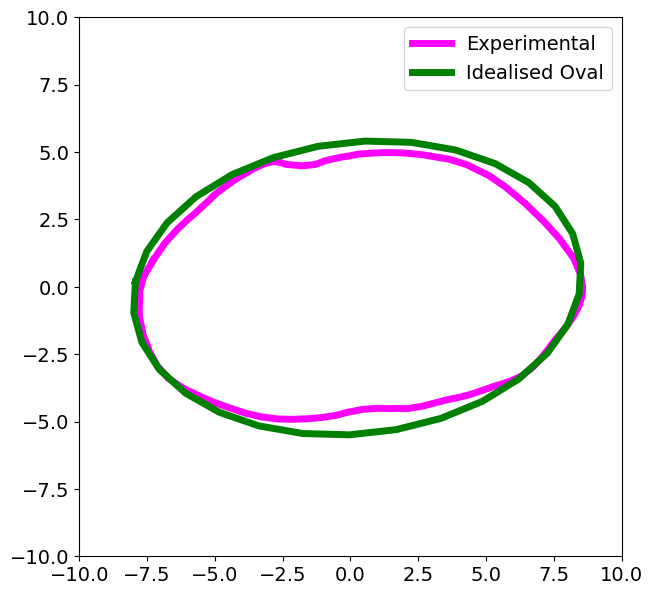

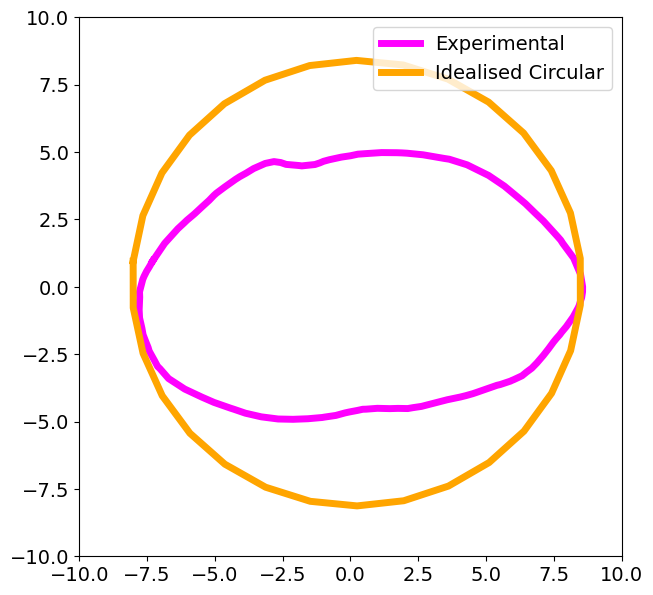

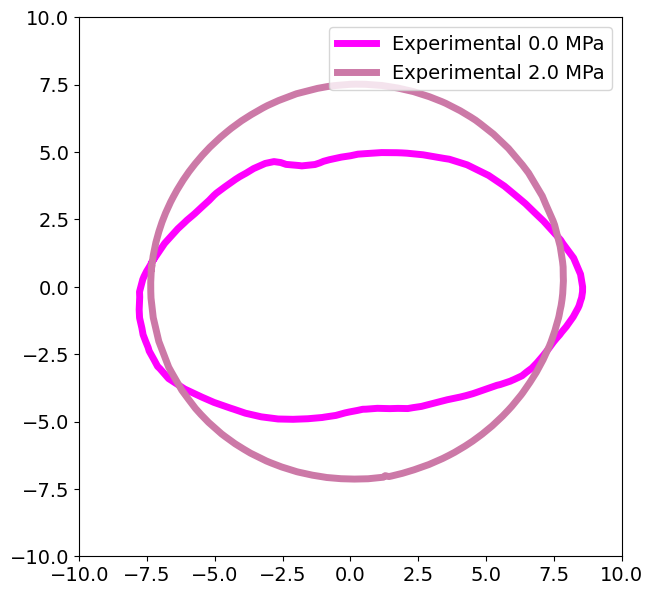

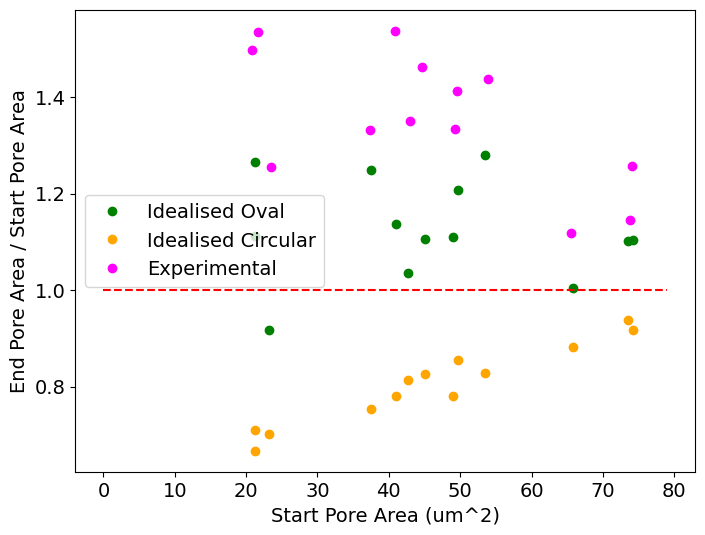

Skipping mesh 3_7 due to missing start or end data in idealised circular.
Oval: Linear regression: slope = 0.461 ± 0.164, intercept = 0.502, Pearson r = 0.646, p-value = 0.0171
Empirical: Linear regression: slope = 0.564 ± 0.246, intercept = 0.600, Pearson r = 0.568, p-value = 0.0427


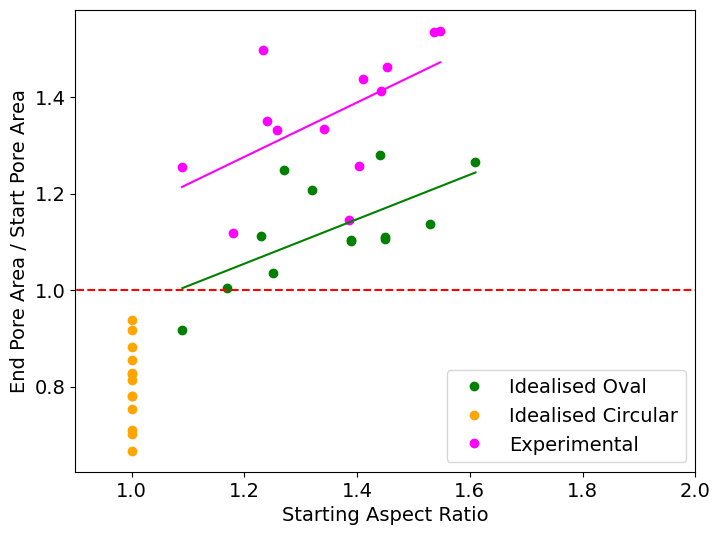

Skipping mesh 3_7 due to missing start or end data in idealised circular.


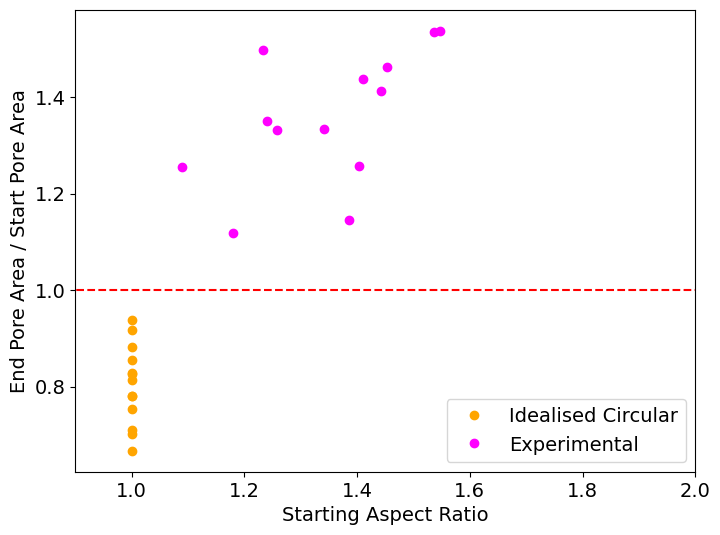

In [5]:
## Figure 3

import importlib
import plot_fig3 as pf3
importlib.reload(pf3)

oval_path = "../Meshes/Idealised/idealised_final_1_2_oval.ply"
circular_path = "../Meshes/Idealised/idealised_final_1_2_circular.ply"
pf3.run_plot_fig3(idealised_df=idealised_df, colours=colours, oval_path=oval_path, circular_path=circular_path, confocal_df=confocal_df, df_combined = df_combined, selected_meshes=selected_meshes)

## Let's also plot a version that doesn't include the oval data, for Figure 2.
pf3.AR_area_change_no_oval(selected_meshes, df_combined=df_combined, confocal_df = confocal_df, colours = colours)

In [6]:
## Figure 4: Anisotropy
## Plot guard cell length - does this change with inflation?
## Anisotropy - how does this affect opening dynamics?
## Can we show that initial differences in opening are due to geometry, whereas later differences are due to anisotropy?
## Which morphospace do plants need to live in?
import sys
from pathlib import Path
import pandas as pd

src_path = str(Path.cwd().parent / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import cross_section_helpers as csh
import importlib
importlib.reload(csh)
from mesh_functions import process_mesh_pressure
import numpy as np
from concurrent.futures import ProcessPoolExecutor

# Use linspace or round arange to avoid floating-point issues
pressures = np.round(np.arange(0, 2.1, 0.1), 1)

midsection_areas = pd.read_csv("../output/midsection_areas.csv")
area_map = {row['mesh_file']: (row['midsection_area1'], row['midsection_area2']) for _, row in midsection_areas.iterrows()}

# Validate that all selected meshes have area data
for mesh in selected_meshes:
    mesh_file = f"Ac_DA_{mesh}.obj"
    if mesh_file not in area_map:
        print(f"WARNING: No midsection area data found for {mesh_file}")

## Set up whether isotropic or anisotropic
stiffening = "isotropic"

# Update tasks to include midsection areas
tasks = []
for mesh in selected_meshes:
    mesh_file = f"Ac_DA_{mesh}.obj"
    area1, area2 = area_map.get(mesh_file, (None, None))
    if area1 is None or area2 is None:
        print(f"WARNING: Missing area data for {mesh}, using None")
    for p in pressures:
        tasks.append((mesh, p, area1, area2, stiffening))

results_matrix_iso = np.zeros((len(selected_meshes), len(pressures)))

with ProcessPoolExecutor() as executor:
    results_flat = list(executor.map(process_mesh_pressure, tasks))

# Reshape results to (meshes, pressures)
for i, mesh in enumerate(selected_meshes):
    results_matrix_iso[i, :] = results_flat[i*len(pressures):(i+1)*len(pressures)]

# If you want the same structure as before:
results_iso = [list(row) for row in results_matrix_iso]

## Repeat for anisotropic stiffening
stiffening = "anisotropic"

# Update tasks to include midsection areas
tasks = []
for mesh in selected_meshes:
    mesh_file = f"Ac_DA_{mesh}.obj"
    area1, area2 = area_map.get(mesh_file, (None, None))
    for p in pressures:
        tasks.append((mesh, p, area1, area2, stiffening))

results_matrix_aniso = np.zeros((len(selected_meshes), len(pressures)))

with ProcessPoolExecutor() as executor:
    results_flat = list(executor.map(process_mesh_pressure, tasks))

# Reshape results to (meshes, pressures)
for i, mesh in enumerate(selected_meshes):
    results_matrix_aniso[i, :] = results_flat[i*len(pressures):(i+1)*len(pressures)]

# If you want the same structure as before:
results_aniso = [list(row) for row in results_matrix_aniso]

Checking results_matrix_iso for zeros or NaNs:
  Zeros: 0
  NaNs: 0
  Shape: (14, 21)
  Min value: 66.281352620505
  Max value: 83.59762973972832

Checking results_matrix_aniso for zeros or NaNs:
  Zeros: 0
  NaNs: 0
  Shape: (14, 21)
  Min value: 64.55877750284435
  Max value: 85.17992885258539


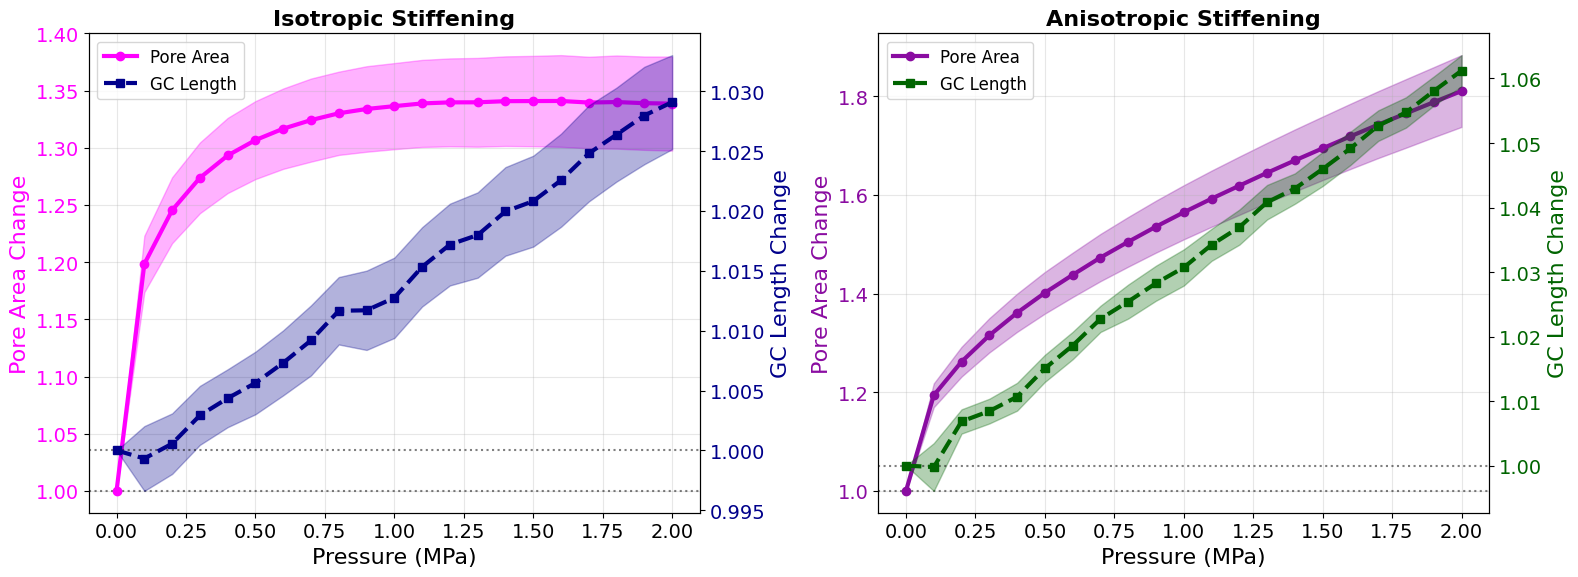

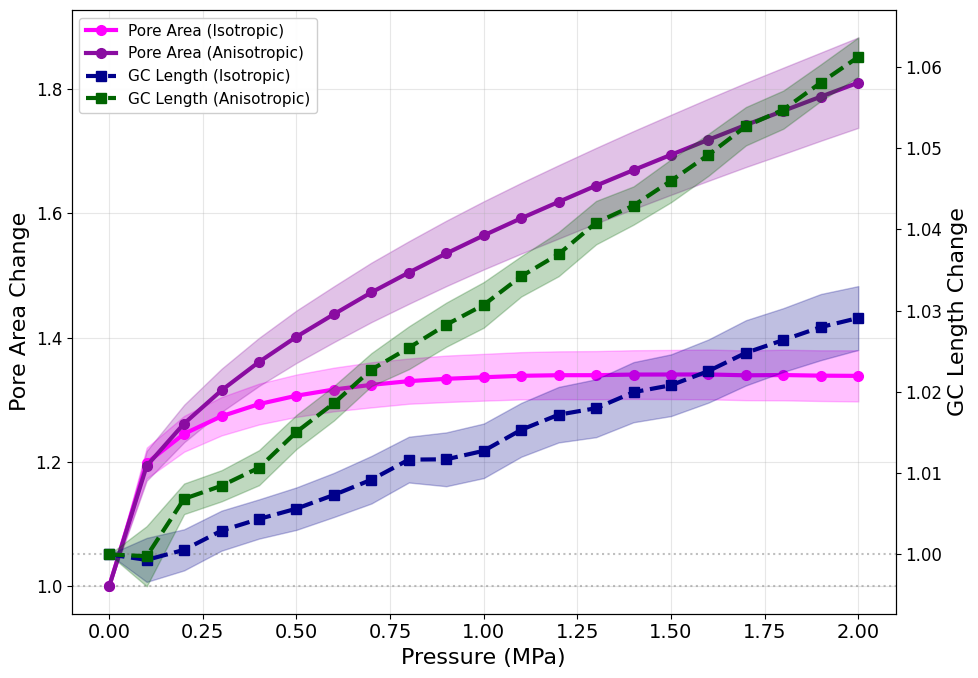


=== Summary Statistics ===
Final GC Length Change (Isotropic): 1.029 ± 0.004
Final GC Length Change (Anisotropic): 1.061 ± 0.002
Final Pore Area Change (Isotropic): 1.339 ± 0.041
Final Pore Area Change (Anisotropic): 1.810 ± 0.073

=== Ratio of Changes ===
Pore Area / GC Length (Isotropic): 11.64x
Pore Area / GC Length (Anisotropic): 13.24x


In [11]:
## Plot Figure 4

import plot_fig4 as pf4
importlib.reload(pf4)

confocal_df_aniso = pd.read_csv("../output/confocal_aniso_results_df_batch.csv")
## Calculate normalized pore area change for all meshes
confocal_df["Pore Area Change"] = np.nan
confocal_df_aniso["Pore Area Change"] = np.nan

pf4.run_plot_fig4(results_matrix_iso, results_matrix_aniso, selected_meshes, confocal_df, confocal_df_aniso, pressures, colours)


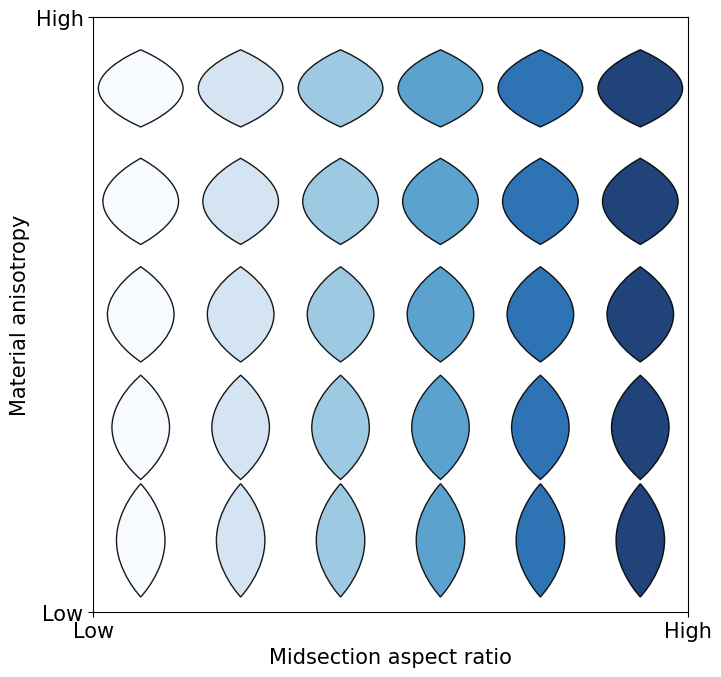

In [ ]:
## Figure 5: Conceptual figure of morphospace for Discussion
from plot_fig5 import run_plot_fig5
run_plot_fig5()


In [20]:
## Let's look at the relationship between pore aspect ratio and change in pore area
import mesh_functions
importlib.reload(mesh_functions)
from mesh_functions import fast_pore_area_fast_ar
from pathlib import Path

results = []

for mesh in selected_meshes:
    mesh_path0 = Path(f"../Meshes/Idealised/pressure_results/idealised_final_mdx_{mesh}_circular_0.0.obj")
    mesh_path2 = Path(f"../Meshes/Idealised/pressure_results/idealised_final_mdx_{mesh}_circular_2.0.obj")
    try:
        row1 = fast_pore_area_fast_ar(mesh_path0)
        row2 = fast_pore_area_fast_ar(mesh_path2)
        results.append(row1)
        results.append(row2)
    except Exception as e:
        print(f"Error processing mesh {mesh}: {e}")

df = pd.DataFrame(results)


Error processing mesh 3_7: string is not a file: `/Users/tomkinsm/stomata-air-mattress/jupyter_notebooks/../Meshes/Idealised/pressure_results/idealised_final_mdx_3_7_circular_0.0.obj`


In [24]:
## Look at the cross sectional areas between the tips and the midsections

def parse_points_string(s):
    import re
    import ast
    import numpy as np
    
    # Remove np.str_('...') or np.str_("...") wrapper if present
    s = re.sub(r"^np\.str_\(['\"](.*)['\"]\)$", r"\1", s.strip())
    
    # Replace newlines with spaces
    s = s.replace('\n', ' ')
    
    # Clean each inner bracketed list
    def fix_inner_list(match):
        nums = re.split(r'[\s,]+', match.group(1).strip())
        nums = [n for n in nums if n]
        return '[' + ', '.join(nums) + ']'
    
    # Apply to all inner bracket groups
    s = re.sub(r'\[([^\[\]]+)\]', fix_inner_list, s)
    
    # Insert commas between adjacent lists
    s = re.sub(r'\]\s*\[', '], [', s)
    
    # Remove double spaces and trailing commas
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r',\s*\]', ']', s)
    
    # Parse safely
    points = ast.literal_eval(s)
    return np.array(points, dtype=float)


tip_area = []
mid_area = []

for mesh in selected_meshes:
    df_mesh = confocal_df[(confocal_df["Mesh ID"] == mesh) & (confocal_df["Pressure"] == 0.0)].copy()

    df_mesh["Midsection Points Left"] = df_mesh["Midsection Points Left"].apply(parse_points_string)
    df_mesh["Midsection Points Right"] = df_mesh["Midsection Points Right"].apply(parse_points_string)
    df_mesh["Tip Points Left"] = df_mesh["Tip Points Left"].apply(parse_points_string)
    df_mesh["Tip Points Right"] = df_mesh["Tip Points Right"].apply(parse_points_string)

    mid_area_left = csh.calculate_cross_section_areas(df_mesh["Midsection Points Left"])
    mid_area_right = csh.calculate_cross_section_areas(df_mesh["Midsection Points Right"])

    tip_area_left = csh.calculate_cross_section_areas(df_mesh["Tip Points Left"])
    tip_area_right = csh.calculate_cross_section_areas(df_mesh["Tip Points Right"])

    tip_area.append([tip_area_left, tip_area_right])
    mid_area.append([mid_area_left, mid_area_right])



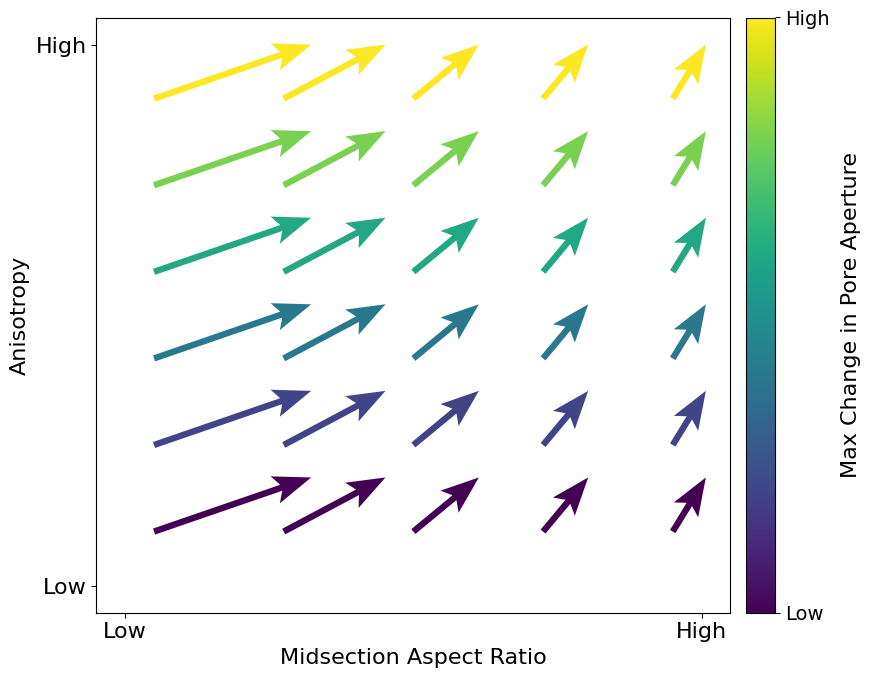

Arrow interpretation:
- All arrows reach the same vertical distance
- Steeper, shorter arrows = higher aspect ratio = faster opening
- Longer, shallower arrows = lower aspect ratio = slower opening
- Color = maximum pore aperture (anisotropy effect)

Speed range: 0.37 to 1.74 (4.7x difference)
Slope range: 0.37 to 1.74 (4.7x difference)
Arrow length range: 0.115 to 0.290

Slope by column (left to right):
  Column 1: slope = 0.37
  Column 2: slope = 0.57
  Column 3: slope = 0.88
  Column 4: slope = 1.28
  Column 5: slope = 1.74


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Reduced grid for better spacing and clearer slope differences
nx, ny = 5, 6  # fewer columns for better spacing
X, Y = np.meshgrid(np.linspace(0.05, 0.95, nx), np.linspace(0.1, 0.9, ny))

# Conceptual relationship:
# - Aspect ratio (X) determines RATE/SPEED of opening (slope)
# - Anisotropy (Y) determines MAX APERTURE (color)

# Define a fixed vertical distance all arrows should reach
target_height = 0.10

# Speed/rate with moderate, more linear progression
# More linear change = easier to see each step
speed = 0.35 + 1.5*X**1.5  # More linear (exponent 1.5), moderate range

# For arrows to reach the same height with different slopes:
V_final = np.ones_like(X) * target_height  # fixed vertical component
U_final = V_final / speed  # horizontal component inversely proportional to speed

# Color represents max aperture increasing with anisotropy (Y)
aperture = 0.2 + 0.8*Y

fig, ax = plt.subplots(figsize=(9, 7))
q = ax.quiver(
    X, Y, U_final, V_final, aperture, 
    scale=1.0,
    cmap='viridis', 
    width=0.010,
    headwidth=4.5,
    headlength=6,
    headaxislength=5,
    angles='xy',
    scale_units='xy'
)

ax.set_xlabel('Midsection Aspect Ratio', fontsize=16)
ax.set_ylabel('Anisotropy', fontsize=16)

# Clean axes
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low', 'High'], fontsize=16)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Low', 'High'], fontsize=16)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

# Colorbar with labels
cbar = plt.colorbar(q, ax=ax, label='Max Change in Pore Aperture', pad=0.02)
cbar.set_label('Max Change in Pore Aperture', fontsize=16, labelpad=8)
cbar.set_ticks([aperture.min(), aperture.max()])
cbar.set_ticklabels(['Low', 'High'], fontsize=14)


# Add clearer annotations with arrows pointing to examples
#ax.annotate('Slow opening\n(long, shallow)', xy=(0.12, 0.5), xytext=(0.25, 0.2),
#            fontsize=12, ha='center', style='italic', alpha=0.8,
#            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7, edgecolor='gray'),
#            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='gray', lw=1.5))

#ax.annotate('Fast opening\n(short, steep)', xy=(0.88, 0.5), xytext=(0.75, 0.2),
#            fontsize=12, ha='center', style='italic', alpha=0.8,
#            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7, edgecolor='gray'),
#            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3', color='gray', lw=1.5))

plt.tight_layout()
plt.savefig("concept.png", dpi=300, bbox_inches='tight')
plt.show()

# Diagnostic info
slopes = V_final / U_final
lengths = np.sqrt(U_final**2 + V_final**2)
print("Arrow interpretation:")
print("- All arrows reach the same vertical distance")
print("- Steeper, shorter arrows = higher aspect ratio = faster opening")
print("- Longer, shallower arrows = lower aspect ratio = slower opening")
print("- Color = maximum pore aperture (anisotropy effect)")
print(f"\nSpeed range: {speed.min():.2f} to {speed.max():.2f} ({speed.max()/speed.min():.1f}x difference)")
print(f"Slope range: {slopes.min():.2f} to {slopes.max():.2f} ({slopes.max()/slopes.min():.1f}x difference)")
print(f"Arrow length range: {lengths.min():.3f} to {lengths.max():.3f}")
print(f"\nSlope by column (left to right):")
for i in range(nx):
    print(f"  Column {i+1}: slope = {slopes[0, i]:.2f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from matplotlib.path import Path
from matplotlib.patches import PathPatch

# Conceptual plot: oval shape encodes final geometry, oval size encodes pressure sensitivity
nx, ny = 6, 5
x = np.linspace(0.08, 0.92, nx)  # pressure requirement (low -> high)
y = np.linspace(0.12, 0.88, ny)  # final pore shape (eccentric -> circular)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(9, 7))

base_height = 0.20          # tallest pore length (bottom rows)
base_width = 0.16
min_width_ratio = 0.45
max_width_ratio = 0.95
min_height_scale = 0.6

min_size_scale = 0.6
max_size_scale = 1.0

for xi, yi in zip(X.ravel(), Y.ravel()):
    width_ratio = min_width_ratio + (max_width_ratio - min_width_ratio) * yi
    height_scale = min_height_scale + (1 - yi) * (1 - min_height_scale)
    size_scale = min_size_scale + (xi - x.min()) / (x.max() - x.min()) * (max_size_scale - min_size_scale)
    ellipse = tapered_pore(
    (xi, yi),
    width=base_width * width_ratio * size_scale,
    height=base_height * height_scale * size_scale,
    color='lightblue',
    edge='darkblue',
    alpha=0.95,
)
    ax.add_patch(ellipse)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low', 'High'], fontsize=15)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Low', 'High'], fontsize=15)
ax.set_ylabel('Material anisotropy', fontsize=15)
ax.set_xlabel('Midsection aspect ratio', fontsize=15)
ax.set_aspect('equal')

# Build legend-like proxy for size encoding
size_examples = np.linspace(min_size_scale, max_size_scale, 3)
handles = []
for scale in size_examples:
    handles.append(
        Ellipse((0, 0),
                width=base_width * size_scale,
                height=base_height * size_scale,
                facecolor='lightgray', edgecolor=cmap(scale), linewidth=1.3)
    )

legend_labels = ['Low sensitivity', 'Moderate', 'High sensitivity']
legend = ax.legend(handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, title='Oval size = sensitivity')
ax.add_artist(legend)

plt.tight_layout()
plt.savefig('concept_ovals_size.png', dpi=300, bbox_inches='tight')
